## Movie Market Analysis
An analytical study of box office performance to provide strategic insights for guiding the development of a new movie studio. This a project from the Moringa Data Science Program.

## Project Objectives
1. Identify the top performing directors and top genres and their effect on the movie market.
2. Identify the top studios and the revenue they generate.
3. To determine which types of movies generate the highest Return on Investment (ROI), using budget and gross revenue data, in order to recommend profitable production strategies for the company new studio.
4. 

In [1]:
import itertools
import numpy as np
import pandas as pd 
from numbers import Number
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile
warnings.filterwarnings('ignore')

import pickle

## Data Preparation

**Loading datasets**  



The dataset used below is ***imdb_movies.csv***, an ***IMDB Movies Dataset from kaggle***. The dataset contains genres, revenue, budget among other columns, making it useful when looking into top performing genres based on their Return On Investment(ROI).

In [2]:
imdb_data = pd.read_csv('data/imdb_movies.csv')
imdb_data.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [3]:
imdb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


Looking at the statistical information of the data using ***.describe***

In [4]:
imdb_data.describe()

,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


Checking for missing values in the dataset

In [5]:
imdb_data.isnull().sum()

names          0
date_x         0
score          0
genre         85
overview       0
crew          56
orig_title     0
status         0
orig_lang      0
budget_x       0
revenue        0
country        0
dtype: int64

Dropping the 85null values in the genre column 

In [6]:
imdb_data = imdb_data.dropna(subset=['genre'])

**Formatting the date column to datetime**

In [7]:
imdb_data['date_x'] = pd.to_datetime(imdb_data['date_x'])
imdb_data.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


Splitting the genres column into individual items e.g.(['Drama', 'Action'] for easier analysis,  grouping, or manipulation since in this case the original column is stored as a single string (e.g., 'Drama, Action')

In [8]:
imdb_data['genre_list'] = imdb_data['genre'].str.split(', ')
imdb_data.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,genre_list
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,"[Drama, Action]"
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,"[Science Fiction, Adventure, Action]"
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,"[Animation, Adventure, Family, Fantasy, Comedy]"
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,"[Animation, Comedy, Family, Adventure, Fantasy]"
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,[Action]


In [9]:
imdb_data['id'] = imdb_data.index + 1
imdb_data.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,genre_list,id
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,"[Drama, Action]",1
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,"[Science Fiction, Adventure, Action]",2
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,"[Animation, Adventure, Family, Fantasy, Comedy]",3
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,"[Animation, Comedy, Family, Adventure, Fantasy]",4
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,[Action],5


Checking if the elements in the genres_list are of the correct type, list.

In [10]:
print(imdb_data['genre_list'].head())
print(imdb_data['genre_list'].apply(type).unique())

0                                    [Drama, Action]
1               [Science Fiction, Adventure, Action]
2    [Animation, Adventure, Family, Fantasy, Comedy]
3    [Animation, Comedy, Family, Adventure, Fantasy]
4                                           [Action]
Name: genre_list, dtype: object
[<class 'list'>]


Ensuring that the genre_list column is processed to break down genre strings into clean, individual genres.



In [11]:
def genre_list1(x):
    if isinstance(x, list):
        new_list = []
        for item in x:
            if isinstance(item, str):
                new_list.extend([genre.strip() for genre in item.split(',')])
            else:
                new_list.append(item)
        return new_list
    elif isinstance(x, str):
              return [genre.strip() for genre in x.split(',')]
    else:
        return []

imdb_data['genre_list1'] = imdb_data['genre_list'].apply(genre_list1)

print(imdb_data['genre_list1'].head())


0                                    [Drama, Action]
1               [Science Fiction, Adventure, Action]
2    [Animation, Adventure, Family, Fantasy, Comedy]
3    [Animation, Comedy, Family, Adventure, Fantasy]
4                                           [Action]
Name: genre_list1, dtype: object


**Analysing the performance of different genres based on Return On Investment(ROI)**

In [12]:
imdb_data['ROI'] = (imdb_data['revenue'] - imdb_data['budget_x']) / imdb_data['budget_x']
imdb_data.exploded = imdb_data.explode('genre_list1')
genre_roi =  imdb_data.exploded.groupby('genre_list1')['ROI'].mean().reset_index()
genre_roi = genre_roi.sort_values(by='ROI', ascending=False)

print(genre_roi.head(10))

        genre_list1            ROI
10           Horror  166342.709790
16         Thriller   99084.540023
6             Drama   71227.593849
7            Family    4020.872125
2         Animation    3850.786580
13          Romance    3612.938999
3            Comedy    1928.906411
14  Science Fiction     297.819623
5       Documentary     263.894383
12          Mystery      73.229459


**Visualization**

1. Top Performing Genres by Average ROI

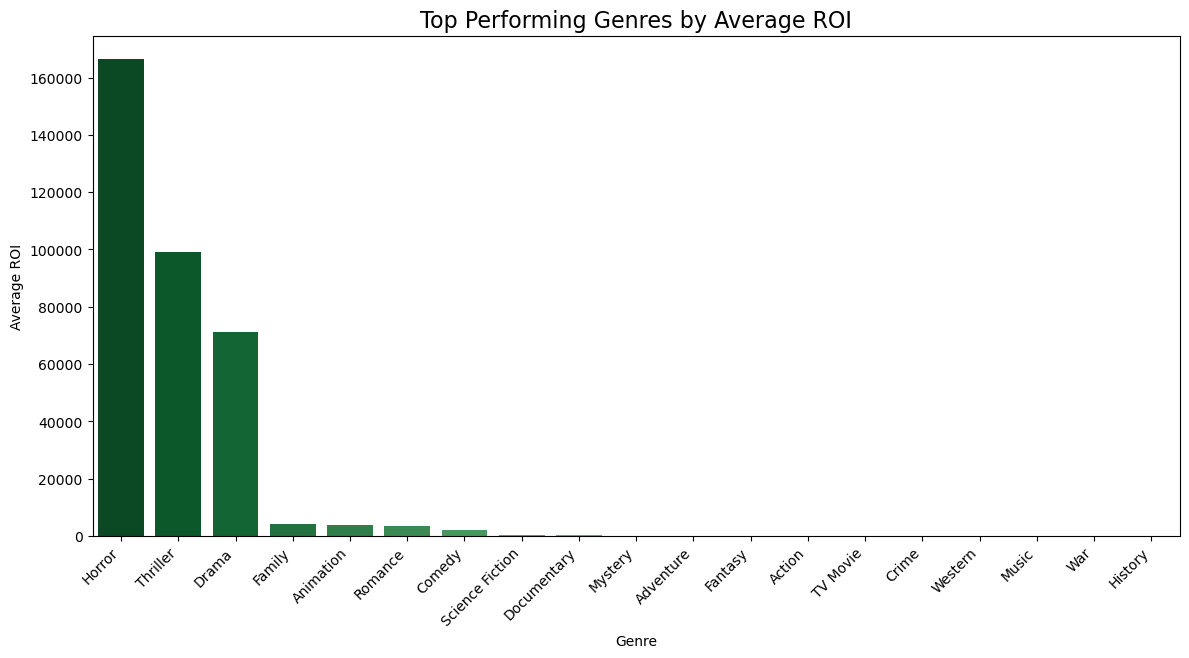

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(data=genre_roi, y='ROI', x='genre_list1', palette='Greens_r')
plt.title('Top Performing Genres by Average ROI', fontsize=16)
plt.ylabel('Average ROI')
plt.xlabel('Genre')
plt.tight_layout()
plt.xticks(rotation=45, ha='right') 
plt.savefig('top_genres_by_roi.png', dpi=300, bbox_inches='tight')
plt.show()

From the graph above, we see that Horror and Thriller genres are the top performers in terms of ROI.
Documentary and Mystery show the lowest ROI.